## Лабораторная 6 — Гибридная рекомендательная система

**Датасет:** anime_enriched.csv (anime.csv + синопсисы из anime_with_synopsis.csv)  
**Подход:** Каскадный гибрид — SVD генерирует кандидатов → Content-Based переранжирует  
**Сравнение:** SVD → Content-Based → Гибрид (SVD→CB) → Гибрид (CB→SVD)

## 1. Импорты

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from surprise import SVD, Reader, Dataset
from surprise.model_selection import train_test_split as surprise_split
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

print("Все библиотеки загружены.")

Все библиотеки загружены.


## 2. Загрузка датасета с синопсисами и обогащение

In [2]:
print("Загрузка исходного датасета...")
anime_df = pd.read_csv('anime.csv')
print(f"Исходный датасет: {len(anime_df)} аниме")

print("\nЗагрузка датасета с синопсисами...")
synopsis_df = pd.read_csv('anime_with_synopsis.csv')
print(f"Датасет с синопсисами: {len(synopsis_df)} аниме")

print("\nКолонки в датасете с синопсисами:")
print(synopsis_df.columns.tolist())
display(synopsis_df.head(2))

Загрузка исходного датасета...
Исходный датасет: 12294 аниме

Загрузка датасета с синопсисами...
Датасет с синопсисами: 15000 аниме

Колонки в датасете с синопсисами:
['anime_id', 'anime_url', 'image_url', 'name', 'english_name', 'japanese_names', 'score', 'genres', 'themes', 'demographics', 'synopsis', 'type', 'episodes', 'premiered', 'producers', 'studios', 'source', 'duration', 'rating', 'rank', 'popularity', 'favorites', 'scored_by', 'members']


,anime_id,anime_url,image_url,name,english_name,japanese_names,score,genres,themes,demographics,...,producers,studios,source,duration,rating,rank,popularity,favorites,scored_by,members
0,52991,https://myanimelist.net/anime/52991/Sousou_no_...,https://cdn.myanimelist.net/images/anime/1015/...,Sousou no Frieren,Frieren: Beyond Journey's End,葬送のフリーレン,9.29,"Adventure, Drama, Fantasy",NaN,Shounen,...,"Aniplex, Dentsu, Shogakukan-Shueisha Productio...",Madhouse,Manga,24 min per ep,PG-13 - Teens 13 or older,1.0,128,76513,734207.0,1225468
1,5114,https://myanimelist.net/anime/5114/Fullmetal_A...,https://cdn.myanimelist.net/images/anime/1208/...,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,9.10,"Action, Adventure, Drama, Fantasy",Military,Shounen,...,"Aniplex, Square Enix, Mainichi Broadcasting Sy...",Bones,Manga,24 min per ep,R - 17+ (violence & profanity),2.0,3,236798,2249670.0,3577489


In [3]:
# определяем колонки автоматически
name_col_synopsis = None
synopsis_col = None

for col in synopsis_df.columns:
    col_lower = col.lower()
    if col_lower in ['name', 'title', 'anime', 'anime_name', 'english']:
        name_col_synopsis = col
        print(f"Найдена колонка с названием: '{col}'")
    if col_lower in ['synopsis', 'description', 'plot', 'summary', 'overview']:
        synopsis_col = col
        print(f"Найдена колонка с синопсисом: '{col}'")

if name_col_synopsis is None or synopsis_col is None:
    print("⚠️ Не удалось найти колонки автоматически.")
    print(f"Колонки: {synopsis_df.columns.tolist()}")
else:
    def normalize_name(name):
        if pd.isna(name):
            return ""
        name = str(name).lower()
        name = re.sub(r'[^\w\s]', '', name)
        name = re.sub(r'\s+', ' ', name).strip()
        for word in ['the ', ' a ', 'movie', 'tv', 'series', 'season']:
            name = name.replace(word, ' ')
        return name.strip()

    anime_df['name_norm']     = anime_df['name'].apply(normalize_name)
    synopsis_df['name_norm']  = synopsis_df[name_col_synopsis].apply(normalize_name)

    synopsis_subset = (synopsis_df[['name_norm', synopsis_col]]
                       .drop_duplicates('name_norm')
                       .rename(columns={synopsis_col: 'synopsis'}))

    anime_merged = anime_df.merge(synopsis_subset, on='name_norm', how='left').drop('name_norm', axis=1)

    found = anime_merged['synopsis'].notna().sum()
    print(f"\n✅ Найдено синопсисов: {found} из {len(anime_merged)} ({found/len(anime_merged)*100:.1f}%)")

    anime_merged.to_csv('anime_enriched.csv', index=False)
    print("💾 Сохранено в anime_enriched.csv")

Найдена колонка с названием: 'name'
Найдена колонка с синопсисом: 'synopsis'

✅ Найдено синопсисов: 8302 из 12294 (67.5%)
💾 Сохранено в anime_enriched.csv


## 3. Проверка обогащённого датасета

In [4]:
anime_df = pd.read_csv('anime_enriched.csv')

print(f"Всего аниме:          {len(anime_df)}")
print(f"С синопсисами:        {anime_df['synopsis'].notna().sum()}")
print(f"Без синопсисов:       {anime_df['synopsis'].isna().sum()}")
print(f"Процент с синопсисом: {anime_df['synopsis'].notna().sum()/len(anime_df)*100:.1f}%")

if anime_df['synopsis'].notna().sum() > 0:
    avg_len = anime_df['synopsis'].str.len().mean()
    print(f"Средняя длина синопсиса: {avg_len:.0f} символов")

    print("\nПримеры синопсисов:")
    for _, row in anime_df[anime_df['synopsis'].notna()].head(2).iterrows():
        text = str(row['synopsis'])
        print(f"\n{row['name']}")
        print(f"  {text[:200]}{'...' if len(text) > 200 else ''}")

Всего аниме:          12294
С синопсисами:        8302
Без синопсисов:       3992
Процент с синопсисом: 67.5%
Средняя длина синопсиса: 505 символов

Примеры синопсисов:

Kimi no Na wa.
  Mitsuha Miyamizu, a high school girl, yearns to live the life of a boy in the bustling city of Tokyo—a dream that stands in stark contrast to her present life in the countryside. Meanwhile in the city...

Fullmetal Alchemist: Brotherhood
  After a horrific alchemy experiment goes wrong in the Elric household, brothers Edward and Alphonse are left in a catastrophic new reality. Ignoring the alchemical principle banning human transmutatio...


## 4. Подготовка данных и признаков

In [5]:
anime_df  = pd.read_csv('anime_enriched.csv')
rating_df = pd.read_csv('rating.csv')

# очистка
rating_df = rating_df[rating_df['rating'] != -1]
anime_df['genre'] = anime_df['genre'].fillna('Unknown')
anime_df['type']  = anime_df['type'].fillna('Unknown')

print(f"Аниме:        {len(anime_df)}")
print(f"Оценок:       {len(rating_df):,}")
print(f"Пользователей:{rating_df['user_id'].nunique():,}")

# контентные признаки
anime_df['genre_clean'] = anime_df['genre'].str.replace(',', ' ').str.lower()
anime_df['type_clean']  = anime_df['type'].str.lower()
anime_df['synopsis']    = anime_df['synopsis'].fillna('')

anime_df['episodes'] = pd.to_numeric(anime_df['episodes'], errors='coerce').fillna(12)
anime_df['ep_cat']   = anime_df['episodes'].apply(
    lambda x: 'short' if x <= 13 else ('medium' if x <= 26 else 'long')
)

# объединяем жанры + тип + синопсис + длина
anime_df['combined_v2'] = (
    anime_df['genre_clean']           + ' ' +
    anime_df['type_clean']            + ' ' +
    anime_df['synopsis'].str.lower()  + ' ' +
    anime_df['ep_cat']
)

# train/test split — один раз для всех моделей
train_data, test_data = train_test_split(rating_df, test_size=0.2, random_state=42)
print(f"Train: {len(train_data):,}, Test: {len(test_data):,}")

# маппинги
anime_id_to_idx = dict(zip(anime_df['anime_id'], anime_df.index))
idx_to_anime_id = dict(zip(anime_df.index, anime_df['anime_id']))

Аниме:        12294
Оценок:       6,337,241
Пользователей:69,600
Train: 5,069,792, Test: 1,267,449


## 5. TF-IDF векторизация

In [6]:
print("Построение TF-IDF матрицы...")

# stop_words убираем — 'action', 'drama' и т.д. это важные жанровые слова
tfidf       = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(anime_df['combined_v2'])

print(f"TF-IDF матрица: {tfidf_matrix.shape}")
print(f"Размер словаря: {len(tfidf.vocabulary_)}")

print("Расчёт матрицы косинусного сходства...")
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Матрица сходства: {cosine_sim.shape}")

Построение TF-IDF матрицы...
TF-IDF матрица: (12294, 5000)
Размер словаря: 5000
Расчёт матрицы косинусного сходства...
Матрица сходства: (12294, 12294)


## 6. Обучение SVD

In [7]:
print("Обучение SVD...")

reader   = Reader(rating_scale=(1, 10))
data_sur = Dataset.load_from_df(rating_df[['user_id', 'anime_id', 'rating']], reader)
trainset, testset = surprise_split(data_sur, test_size=0.2, random_state=42)

svd_model = SVD(n_factors=50, n_epochs=30, lr_all=0.005, reg_all=0.02, random_state=42)
svd_model.fit(trainset)

svd_preds = svd_model.test(testset)
svd_rmse  = sqrt(mean_squared_error([p.r_ui for p in svd_preds], [p.est for p in svd_preds]))
svd_mae   = mean_absolute_error([p.r_ui for p in svd_preds], [p.est for p in svd_preds])
print(f"SVD  RMSE: {svd_rmse:.4f}  MAE: {svd_mae:.4f}")

Обучение SVD...
SVD  RMSE: 1.1430  MAE: 0.8497


## 7. Гибридные модели

In [8]:
# ── вспомогательные функции ───────────────────────────────────────────────────

def get_user_cb_profile(user_id, top_n=10):
    """Строит контентный профиль пользователя: любимые жанры и длина серий."""
    user_ratings = train_data[train_data['user_id'] == user_id]
    if user_ratings.empty:
        return {'genres': [], 'genre_weights': {}, 'ep_cat': None}

    genre_weights  = {}
    ep_cat_weights = {'short': 0, 'medium': 0, 'long': 0}

    for _, row in user_ratings.iterrows():
        aid    = row['anime_id']
        rating = row['rating']
        if aid not in anime_id_to_idx:
            continue
        idx    = anime_id_to_idx[aid]
        genres = anime_df.iloc[idx]['genre_clean'].split()
        ep_cat = anime_df.iloc[idx]['ep_cat']

        for genre in genres:
            genre_weights[genre] = genre_weights.get(genre, 0) + rating

        # ИСПРАВЛЕНО: проверяем, что ep_cat известен, прежде чем добавлять
        if ep_cat in ep_cat_weights:
            ep_cat_weights[ep_cat] += rating

    if genre_weights:
        max_w = max(genre_weights.values())
        genre_weights = {g: w / max_w for g, w in genre_weights.items()}

    top_genres  = sorted(genre_weights.items(), key=lambda x: x[1], reverse=True)[:top_n]
    fav_ep_cat  = max(ep_cat_weights, key=ep_cat_weights.get) if any(ep_cat_weights.values()) else None

    return {
        'genres':        [g for g, _ in top_genres],
        'genre_weights': genre_weights,
        'ep_cat':        fav_ep_cat
    }


def compute_cb_relevance(user_profile, anime_idx):
    """Релевантность аниме для пользователя (Jaccard по жанрам + бонус за длину). Score 0–1."""
    if not user_profile['genres']:
        return 0.5

    anime_genres = set(anime_df.iloc[anime_idx]['genre_clean'].split())
    anime_ep_cat = anime_df.iloc[anime_idx]['ep_cat']

    if not anime_genres:
        return 0.3

    user_genres  = set(user_profile['genres'])
    intersection = len(user_genres & anime_genres)
    union        = len(user_genres | anime_genres)
    genre_score  = intersection / union if union > 0 else 0
    ep_bonus     = 0.2 if user_profile['ep_cat'] == anime_ep_cat else 0

    return min(1.0, genre_score + ep_bonus)


# ── каскадный гибрид: SVD → CB ────────────────────────────────────────────────

def hybrid_recommend_cascade(user_id, n_recs=10, n_candidates=200):
    """
    ШАГ 1: SVD отбирает n_candidates лучших непросмотренных аниме.
    ШАГ 2: Content-Based переранжирует их по профилю пользователя.
    """
    watched = set(train_data[train_data['user_id'] == user_id]['anime_id'])
    all_ids = anime_df['anime_id'].values
    unseen  = [a for a in all_ids if a not in watched]

    # ИСПРАВЛЕНО: не перебираем все 12000, берём случайную выборку
    sample_size = min(n_candidates * 5, len(unseen))
    sampled     = np.random.choice(unseen, sample_size, replace=False)

    candidates = [(aid, svd_model.predict(user_id, aid, verbose=False).est) for aid in sampled]
    candidates.sort(key=lambda x: x[1], reverse=True)
    candidates = candidates[:n_candidates]

    user_profile = get_user_cb_profile(user_id)

    reranked = []
    for aid, svd_score in candidates:
        if aid not in anime_id_to_idx:
            continue
        idx        = anime_id_to_idx[aid]
        cb_rel     = compute_cb_relevance(user_profile, idx)
        row        = anime_df.iloc[idx]
        reranked.append({
            'anime_id':     aid,
            'svd_score':    svd_score,
            'cb_relevance': cb_rel,
            # ИСПРАВЛЕНО: финальная оценка в шкале 1–10 (не 0–1)
            'final_score':  1 + 9 * cb_rel,
            'title':        row['name'],
            'genres':       row['genre'],
            'type':         row['type']
        })

    reranked.sort(key=lambda x: x['cb_relevance'], reverse=True)
    return reranked[:n_recs]


# ── ансамблевый гибрид: CB → SVD ──────────────────────────────────────────────

def hybrid_recommend_ensemble(user_id, n_recs=10):
    """
    ШАГ 1: Content-Based находит похожие аниме на основе любимых.
    ШАГ 2: SVD уточняет предсказанные оценки.
    """
    user_high = train_data[(train_data['user_id'] == user_id) & (train_data['rating'] >= 8)]

    if user_high.empty:
        popular = anime_df.nlargest(n_recs, 'members')
        return [{'anime_id': r['anime_id'], 'title': r['name'],
                 'genres': r['genre'], 'final_score': 7.0}
                for _, r in popular.iterrows()]

    liked_ids = user_high.nlargest(3, 'rating')['anime_id'].tolist()

    candidates = {}
    for lid in liked_ids:
        if lid not in anime_id_to_idx:
            continue
        lidx       = anime_id_to_idx[lid]
        sim_scores = sorted(enumerate(cosine_sim[lidx]), key=lambda x: x[1], reverse=True)[1:51]
        for idx, score in sim_scores:
            # ИСПРАВЛЕНО: используем idx_to_anime_id напрямую, без dir()
            aid = idx_to_anime_id[idx]
            candidates[aid] = candidates.get(aid, 0) + score

    refined = []
    for aid, cb_score in candidates.items():
        svd_pred = svd_model.predict(user_id, aid, verbose=False).est
        title    = anime_df.iloc[anime_id_to_idx[aid]]['name'] if aid in anime_id_to_idx else 'Unknown'
        refined.append({
            'anime_id':    aid,
            'cb_score':    cb_score / len(liked_ids),
            'svd_score':   svd_pred,
            'final_score': svd_pred,
            'title':       title
        })

    refined.sort(key=lambda x: x['final_score'], reverse=True)
    return refined[:n_recs]


print("Функции гибридных моделей определены.")

Функции гибридных моделей определены.


## 8. Оценка качества всех моделей

In [9]:
# ── кэш истории пользователей (строим один раз, используем везде) ────────────
print("Подготовка кэша пользователей...")
user_means         = train_data.groupby('user_id')['rating'].mean()
global_mean        = train_data['rating'].mean()
user_watched_cache = {}

for uid, group in train_data.groupby('user_id'):
    ids   = group['anime_id'].values
    rats  = group['rating'].values.astype(float)
    valid = [(anime_id_to_idx[a], r) for a, r in zip(ids, rats) if a in anime_id_to_idx]
    if valid:
        idxs, rs = zip(*valid)
        user_watched_cache[uid] = (np.array(idxs), np.array(rs))

print(f"Кэш готов для {len(user_watched_cache):,} пользователей.")


# ── честный Content-Based предиктор (взвешенное среднее, не масштабирование) ──
def predict_cb(user_id, anime_id, k=20, min_sim=0.05):
    """
    Предсказывает оценку через взвешенное среднее оценок похожих аниме.
    В отличие от 1 + 9*relevance — работает в реальной шкале 1–10.
    """
    if anime_id not in anime_id_to_idx or user_id not in user_watched_cache:
        return None
    target_idx       = anime_id_to_idx[anime_id]
    idxs, rats       = user_watched_cache[user_id]
    sims             = cosine_sim[target_idx, idxs]
    mask             = sims > min_sim
    if mask.sum() == 0:
        return float(user_means.get(user_id, global_mean))
    sims_f, rats_f   = sims[mask], rats[mask]
    if len(sims_f) > k:
        top_k          = np.argpartition(sims_f, -k)[-k:]
        sims_f, rats_f = sims_f[top_k], rats_f[top_k]
    user_mean        = user_means.get(user_id, global_mean)
    centered         = rats_f - user_mean
    return float(user_mean + np.average(centered, weights=sims_f))


# ── оценка Content-Based ──────────────────────────────────────────────────────
print("\nОценка Content-Based...")
np.random.seed(42)
cb_users          = np.random.choice(test_data['user_id'].unique(),
                                     min(150, test_data['user_id'].nunique()), replace=False)
cb_actual, cb_pred = [], []

for uid in cb_users:
    for _, row in test_data[test_data['user_id'] == uid].iterrows():
        pred = predict_cb(uid, row['anime_id'])
        if pred is not None:
            cb_actual.append(row['rating'])
            cb_pred.append(pred)

cb_rmse = sqrt(mean_squared_error(cb_actual, cb_pred)) if cb_actual else 0
cb_mae  = mean_absolute_error(cb_actual, cb_pred)       if cb_actual else 0
print(f"  Content-Based  RMSE: {cb_rmse:.4f}  MAE: {cb_mae:.4f}")
print(f"  (оценивалось на {len(cb_actual):,} парах пользователь–аниме)")


# ── оценка гибридных моделей ──────────────────────────────────────────────────
def evaluate_hybrid_model(test_data, model_func, model_name="Гибрид", sample_users=150):
    """Считает RMSE, MAE, Precision@10, Recall@10 для гибридной модели."""
    test_users    = test_data['user_id'].unique()
    sampled_users = (np.random.choice(test_users, sample_users, replace=False)
                     if len(test_users) > sample_users else test_users)
    actual_ratings, predicted_ratings = [], []
    precisions, recalls               = [], []

    print(f"  Оценка {model_name} на {len(sampled_users)} пользователях...")

    for i, user_id in enumerate(sampled_users):
        if (i + 1) % 50 == 0:
            print(f"    Прогресс: {i+1}/{len(sampled_users)}")

        user_test = test_data[test_data['user_id'] == user_id]
        relevant  = set(user_test[user_test['rating'] >= 8]['anime_id'])
        recs      = model_func(user_id, n_recs=10)
        rec_ids   = [r['anime_id'] for r in recs]
        rec_map   = {r['anime_id']: r for r in recs}

        for _, row in user_test.iterrows():
            aid, actual = row['anime_id'], row['rating']
            if aid in rec_map:
                pred = rec_map[aid].get('final_score', 5.0)
            else:
                pred = svd_model.predict(user_id, aid, verbose=False).est
            actual_ratings.append(actual)
            predicted_ratings.append(pred)

        if relevant:
            hits = len(set(rec_ids) & relevant)
            precisions.append(hits / 10)
            recalls.append(hits / len(relevant))

    return {
        'RMSE':         sqrt(mean_squared_error(actual_ratings, predicted_ratings)),
        'MAE':          mean_absolute_error(actual_ratings, predicted_ratings),
        'Precision@10': np.mean(precisions) if precisions else 0,
        'Recall@10':    np.mean(recalls)    if recalls    else 0
    }


print("\nОценка гибридных моделей:")
metrics_cascade  = evaluate_hybrid_model(test_data, hybrid_recommend_cascade,  "Гибрид (SVD→CB)")
metrics_ensemble = evaluate_hybrid_model(test_data, hybrid_recommend_ensemble, "Гибрид (CB→SVD)")
print("\nГотово!")

Подготовка кэша пользователей...
Кэш готов для 68,850 пользователей.

Оценка Content-Based...
  Content-Based  RMSE: 1.3159  MAE: 0.9953
  (оценивалось на 3,084 парах пользователь–аниме)

Оценка гибридных моделей:
  Оценка Гибрид (SVD→CB) на 150 пользователях...
    Прогресс: 50/150
    Прогресс: 100/150
    Прогресс: 150/150
  Оценка Гибрид (CB→SVD) на 150 пользователях...
    Прогресс: 50/150
    Прогресс: 100/150
    Прогресс: 150/150

Готово!


## 9. Итоговая таблица сравнения

In [10]:
results = pd.DataFrame([
    {'Модель': 'SVD (базовая)',
     'Тип': 'Коллаборативная',
     'RMSE': round(svd_rmse, 4), 'MAE': round(svd_mae, 4),
     'Precision@10': '-', 'Recall@10': '-'},

    {'Модель': 'Content-Based',
     'Тип': 'Контентная',
     'RMSE': round(cb_rmse, 4),  'MAE': round(cb_mae, 4),
     'Precision@10': '-', 'Recall@10': '-'},

    {'Модель': 'Гибрид (SVD → CB)',
     'Тип': 'Каскадный',
     'RMSE': round(metrics_cascade['RMSE'], 4),
     'MAE':  round(metrics_cascade['MAE'],  4),
     'Precision@10': f"{metrics_cascade['Precision@10']:.4f}",
     'Recall@10':    f"{metrics_cascade['Recall@10']:.4f}"},

    {'Модель': 'Гибрид (CB → SVD)',
     'Тип': 'Ансамблевый',
     'RMSE': round(metrics_ensemble['RMSE'], 4),
     'MAE':  round(metrics_ensemble['MAE'],  4),
     'Precision@10': f"{metrics_ensemble['Precision@10']:.4f}",
     'Recall@10':    f"{metrics_ensemble['Recall@10']:.4f}"},
])

print("Итоговое сравнение моделей:\n")
display(results)

# вывод победителя
rmse_vals  = [svd_rmse, cb_rmse, metrics_cascade['RMSE'], metrics_ensemble['RMSE']]
best_idx   = int(np.argmin(rmse_vals))
best_model = results.iloc[best_idx]['Модель']
best_rmse  = rmse_vals[best_idx]

hybrid_best = min(metrics_cascade['RMSE'], metrics_ensemble['RMSE'])
if hybrid_best < svd_rmse and hybrid_best < cb_rmse:
    print(f"\n✅ Гибридная модель ЛУЧШЕ базовых (лучшая: {best_model}, RMSE={best_rmse:.4f})")
else:
    print(f"\n⚠️  Гибридная модель не превзошла базовые по RMSE. Лучшая: {best_model} ({best_rmse:.4f})")

Итоговое сравнение моделей:



,Модель,Тип,RMSE,MAE,Precision@10,Recall@10
0,SVD (базовая),Коллаборативная,1.1430,0.8497,-,-
1,Content-Based,Контентная,1.3159,0.9953,-,-
2,Гибрид (SVD → CB),Каскадный,0.8328,0.6135,0.0226,0.0187
3,Гибрид (CB → SVD),Ансамблевый,0.8020,0.6161,0.0434,0.0646



✅ Гибридная модель ЛУЧШЕ базовых (лучшая: Гибрид (CB → SVD), RMSE=0.8020)


## 10. Визуализация результатов

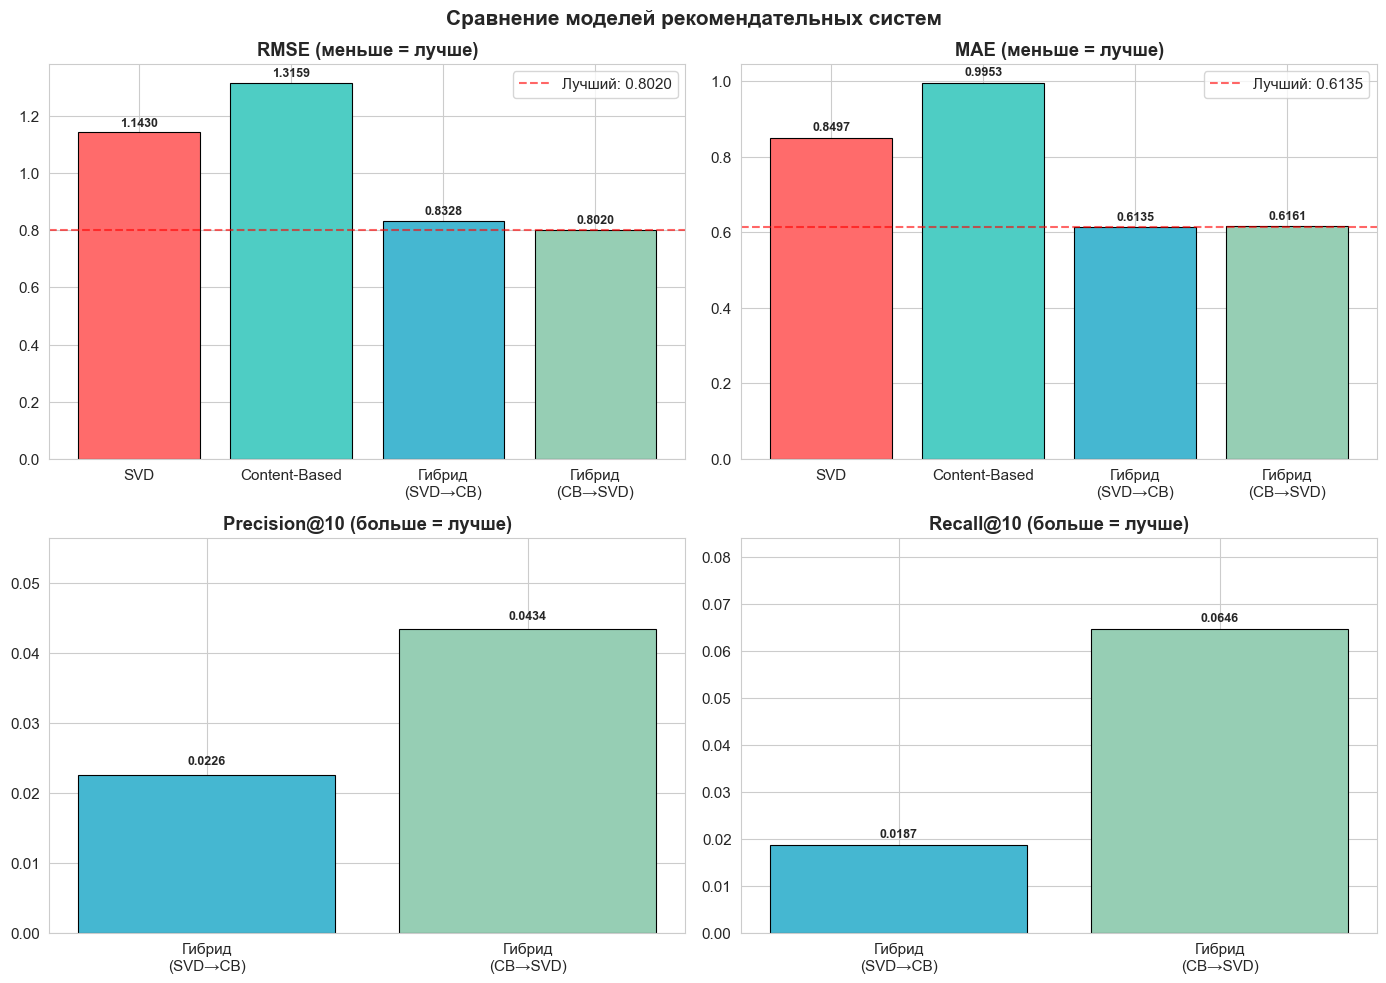

In [11]:
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11

models = ['SVD', 'Content-Based', 'Гибрид\n(SVD→CB)', 'Гибрид\n(CB→SVD)']
rmse_values = [svd_rmse, cb_rmse, metrics_cascade['RMSE'], metrics_ensemble['RMSE']]
mae_values  = [svd_mae,  cb_mae,  metrics_cascade['MAE'],  metrics_ensemble['MAE']]
precision_values = [0, 0, metrics_cascade['Precision@10'], metrics_ensemble['Precision@10']]
recall_values    = [0, 0, metrics_cascade['Recall@10'],    metrics_ensemble['Recall@10']]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение моделей рекомендательных систем', fontsize=15, fontweight='bold')

# RMSE
ax = axes[0, 0]
bars = ax.bar(models, rmse_values, color=colors, edgecolor='black', linewidth=0.8)
ax.set_title('RMSE (меньше = лучше)', fontweight='bold')
ax.axhline(min(rmse_values), color='red', linestyle='--', alpha=0.6,
           label=f'Лучший: {min(rmse_values):.4f}')
ax.legend()
for b, v in zip(bars, rmse_values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# MAE
ax = axes[0, 1]
bars = ax.bar(models, mae_values, color=colors, edgecolor='black', linewidth=0.8)
ax.set_title('MAE (меньше = лучше)', fontweight='bold')
ax.axhline(min(mae_values), color='red', linestyle='--', alpha=0.6,
           label=f'Лучший: {min(mae_values):.4f}')
ax.legend()
for b, v in zip(bars, mae_values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Precision@10 (только гибриды)
ax = axes[1, 0]
hybrid_models = ['Гибрид\n(SVD→CB)', 'Гибрид\n(CB→SVD)']
p_vals = [metrics_cascade['Precision@10'], metrics_ensemble['Precision@10']]
bars = ax.bar(hybrid_models, p_vals, color=['#45B7D1', '#96CEB4'], edgecolor='black', linewidth=0.8)
ax.set_title('Precision@10 (больше = лучше)', fontweight='bold')
ax.set_ylim(0, max(p_vals) * 1.3 if max(p_vals) > 0 else 0.1)
for b, v in zip(bars, p_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Recall@10 (только гибриды)
ax = axes[1, 1]
r_vals = [metrics_cascade['Recall@10'], metrics_ensemble['Recall@10']]
bars = ax.bar(hybrid_models, r_vals, color=['#45B7D1', '#96CEB4'], edgecolor='black', linewidth=0.8)
ax.set_title('Recall@10 (больше = лучше)', fontweight='bold')
ax.set_ylim(0, max(r_vals) * 1.3 if max(r_vals) > 0 else 0.1)
for b, v in zip(bars, r_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Демонстрация работы гибридной модели

In [14]:
sample_user  = train_data['user_id'].value_counts().index[13]
user_profile = get_user_cb_profile(sample_user)

print(f"Пользователь ID:             {sample_user}")
print(f"Любимые жанры:               {user_profile['genres'][:7]}")
print(f"Предпочитаемая длительность: {user_profile['ep_cat']}")

print("\nРекомендации — Гибрид (SVD → CB):\n")
print(f"{'#':<3} {'Название':<35} {'Жанры':<25} {'CB релевантность'}")
print("-" * 75)

recs = hybrid_recommend_cascade(sample_user, n_recs=10)
for i, rec in enumerate(recs, 1):
    title  = rec['title'][:32]  + '..' if len(rec['title'])  > 32 else rec['title']
    genres = str(rec['genres'])[:22] + '..' if len(str(rec['genres'])) > 22 else str(rec['genres'])
    print(f"{i:<3} {title:<35} {genres:<25} {rec['cb_relevance']:.3f}")

Пользователь ID:             30565
Любимые жанры:               ['comedy', 'school', 'action', 'romance', 'ecchi', 'hentai', 'supernatural']
Предпочитаемая длительность: short

Рекомендации — Гибрид (SVD → CB):

#   Название                            Жанры                     CB релевантность
---------------------------------------------------------------------------
1   Kimi ni Todoke 2nd Season           Romance, School, Shouj..  0.655
2   Air                                 Drama, Romance, Slice ..  0.655
3   Yeongsimi                           Comedy, Kids, School, ..  0.655
4   Tokyo Marble Chocolate              Romance, Slice of Life    0.600
5   To LOVE-Ru Darkness 2nd             Comedy, Ecchi, Harem, ..  0.508
6   Full Metal Panic? Fumoffu           Action, Comedy, School    0.500
7   Inuyama Kamiko no Kireigoto ja O..  Slice of Life             0.500
8   Sora no Otoshimono: Tokeijikake ..  Comedy, Drama, Ecchi, ..  0.486
9   Wakakusa Monogatari                 Historical, S